In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
datasets = {
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "portfolio": portfolio
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name.upper())
    print(df.columns.tolist())


AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

PORTFOLIO
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'curre

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Funds"
)

fig.show()

In [6]:
fig.write_html("../reports/nav_trend.html")

### NAV Trend Analysis

The NAV of most mutual fund schemes increased steadily between 2022 and 2026, indicating overall positive fund performance. A few schemes significantly outperformed others with higher NAV growth, while no major market-wide decline was observed during the period.

In [7]:
aum["date"].unique()

array(['2022-03-31', '2022-09-30', '2023-03-31', '2023-09-30',
       '2024-03-31', '2024-09-30', '2024-12-31', '2025-03-31',
       '2025-12-31'], dtype=object)

In [8]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum[["date", "year"]].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


In [9]:
aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .mean()
    .reset_index()
)

aum_yearly.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,281500.0
1,2022,Axis Mutual Fund,245000.0
2,2022,DSP Mutual Fund,111000.0
3,2022,HDFC Mutual Fund,440000.0
4,2022,ICICI Prudential MF,476500.0


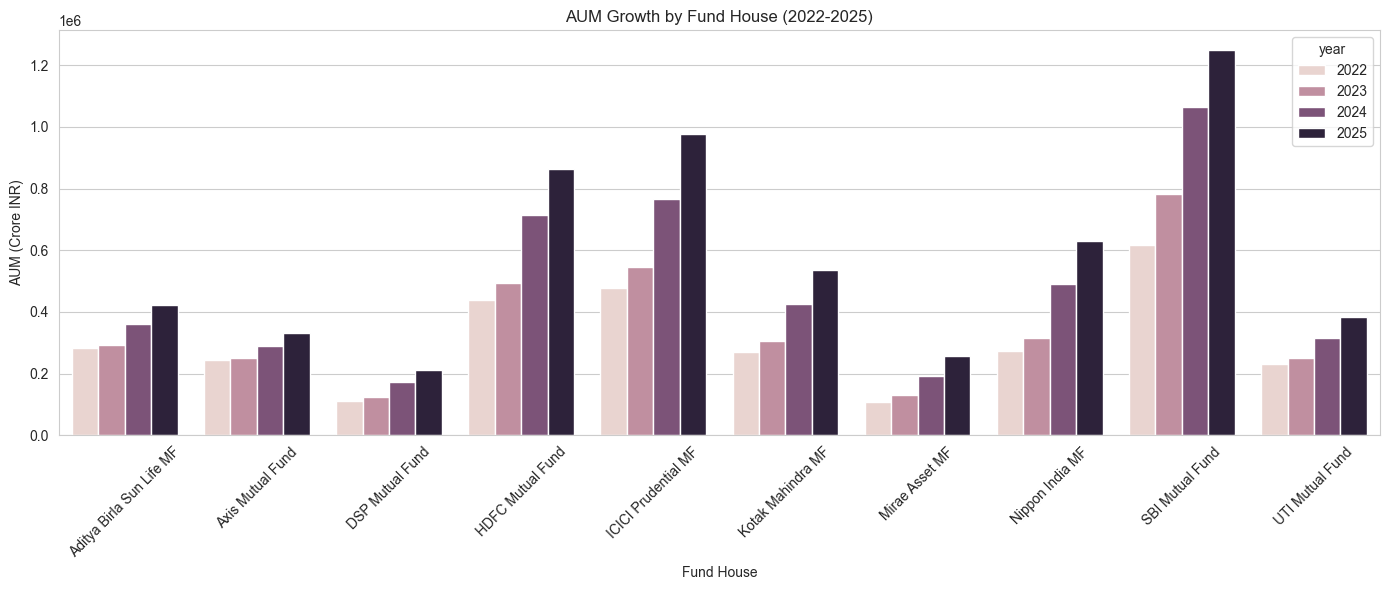

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_crore',
    hue='year'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (Crore INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/aum_growth.png")
plt.show()

# AUM Growth Analysis

Assets Under Management (AUM) increased across most fund houses between 2022 and 2025. SBI Mutual Fund maintained the highest AUM throughout the period, followed by ICICI Prudential MF and HDFC Mutual Fund. The consistent increase in AUM indicates growing investor participation and expansion of the mutual fund industry.

In [11]:
import plotly.express as px

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.show()

fig.write_html("../reports/sip_inflow_trend.html")

## SIP Inflow Analysis

Monthly SIP inflows increased steadily from around ₹11,500 crore in early 2022 to more than ₹30,000 crore by late 2025, reflecting growing retail investor participation and confidence in mutual fund investments.

In [12]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

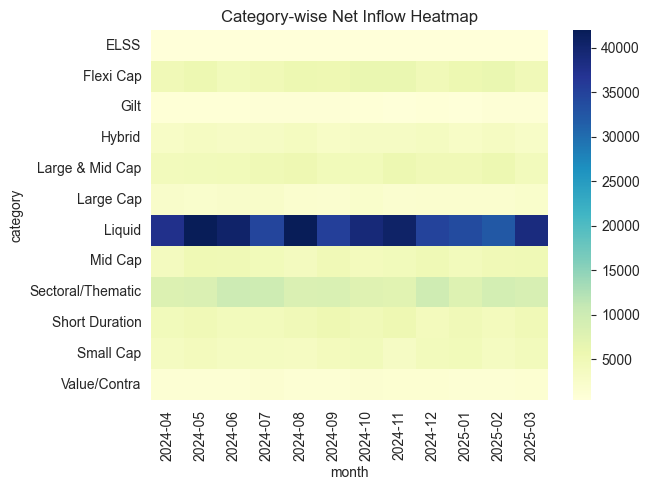

In [13]:
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)
plt.title("Category-wise Net Inflow Heatmap")
plt.savefig("../reports/category_heatmap.png")
plt.show()

# Category Inflow Heatmap Analysis

The heatmap shows the variation in net inflows across mutual fund categories over different months. Liquid funds consistently attracted the highest inflows, indicating strong investor preference for low-risk and highly liquid investment options. Categories such as Flexi Cap, Large & Mid Cap, and Sectoral/Thematic funds also received significant inflows during certain periods. In contrast, ELSS and Gilt funds recorded comparatively lower inflows. Overall, investor interest remained concentrated in a few major categories throughout the observed period.

In [14]:
age_distribution = (
    transactions.groupby("age_group")["amount_inr"]
    .sum()
    .reset_index()
)

age_distribution

,age_group,amount_inr
0,18-25,531639392
1,26-35,1451600218
2,36-45,871647528
3,46-55,405406469
4,56+,261286823


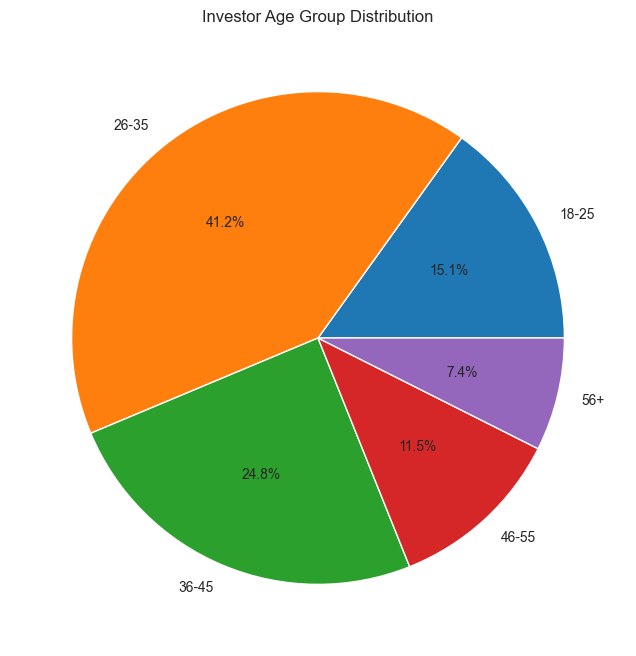

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution["amount_inr"],
    labels=age_distribution["age_group"],
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/age_group_distribution.png")

plt.show()

# Investor Age Group Distribution Analysis

The age group 26–35 contributed the highest share of mutual fund investments, indicating strong participation from young working professionals. Investors aged 36–45 formed the second-largest segment, while the 56+ age group accounted for the smallest share. The distribution suggests that mutual fund investments are primarily driven by middle-aged and early-career investors.

In [16]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

In [17]:
gender_distribution = (
    transactions.groupby("gender")["amount_inr"]
    .sum()
    .reset_index()
)

gender_distribution

,gender,amount_inr
0,Female,1176346701
1,Male,2345233729


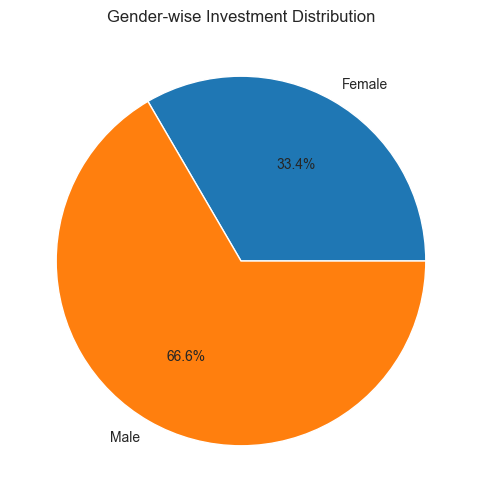

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    gender_distribution["amount_inr"],
    labels=gender_distribution["gender"],
    autopct="%1.1f%%"
)

plt.title("Gender-wise Investment Distribution")

plt.savefig("../reports/gender_distribution.png")

plt.show()

## Gender-wise Investment Distribution

Male investors account for the majority of total investments, contributing nearly two-thirds of the total invested amount. Female investors contribute approximately one-third of the total investment value. This distribution reflects higher participation and investment activity among male investors in the dataset.

In [19]:
category_returns = (
    performance.groupby("category")["return_3yr_pct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_returns

,category,return_3yr_pct
0,Small Cap,21.686667
1,Mid Cap,16.590000
2,Flexi Cap,15.495000
3,Value,14.760000
4,Large & Mid Cap,14.560000
5,ELSS,13.580000
6,Large Cap,12.985714
7,Index,12.100000
8,Index/ETF,11.770000
9,Short Duration,7.370000


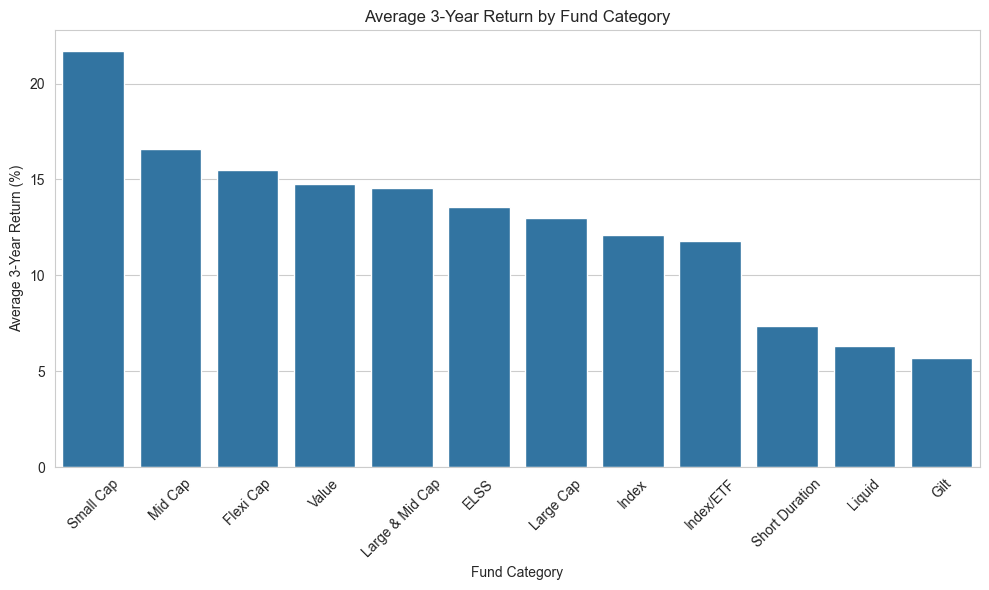

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_returns,
    x="category",
    y="return_3yr_pct"
)

plt.title("Average 3-Year Return by Fund Category")
plt.xlabel("Fund Category")
plt.ylabel("Average 3-Year Return (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/category_returns.png")

plt.show()

## Fund Category Performance Analysis

Small Cap funds delivered the highest average 3-year return among all fund categories, followed by Mid Cap and Flexi Cap funds. Equity-oriented categories generally outperformed debt-oriented categories such as Liquid and Gilt funds. The analysis indicates that higher-risk categories generated stronger long-term returns during the observed period.

In [21]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [22]:
sector_allocation = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_allocation

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54
5,FMCG,229.11
6,Infrastructure,192.16
7,Diversified,169.23
8,Telecom,145.62
9,Consumer Goods,127.61


## Sector-wise Portfolio Allocation Analysis

This analysis aggregates portfolio weights across sectors to identify which industries receive the highest allocation from mutual fund portfolios. The results highlight sector preferences and concentration trends within the sample funds.

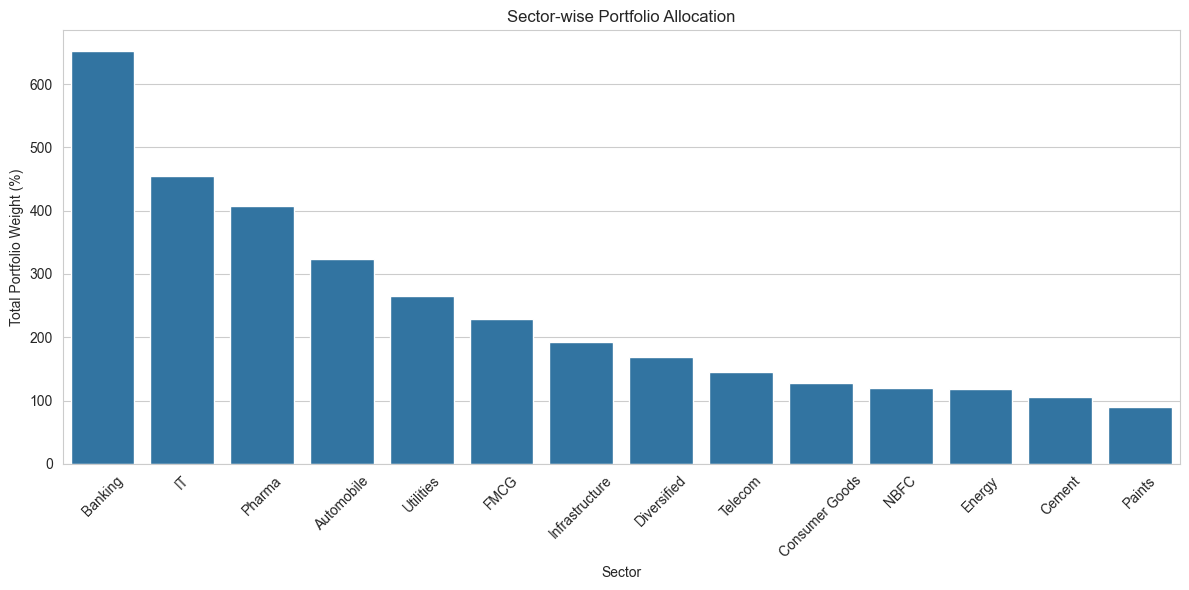

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=sector_allocation,
    x="sector",
    y="weight_pct"
)

plt.title("Sector-wise Portfolio Allocation")
plt.xlabel("Sector")
plt.ylabel("Total Portfolio Weight (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/sector_allocation.png")
plt.show()

## Sector-wise Portfolio Allocation Insights

Banking emerged as the most heavily allocated sector across mutual fund portfolios, followed by Information Technology (IT) and Pharma. This indicates a strong preference among fund managers for sectors that are critical to India's economic growth and corporate earnings. Automobile, Utilities, and FMCG also received significant allocations, while sectors such as Cement and Paints had comparatively lower portfolio exposure. Overall, the allocation pattern suggests a focus on financial services, technology, and healthcare as key investment themes.

In [24]:
top_stocks = (
    holdings.groupby("stock_name")
    .size()
    .reset_index(name="fund_count")
    .sort_values("fund_count", ascending=False)
    .head(10)
)

top_stocks

,stock_name,fund_count
4,Bharti Airtel Ltd,15
8,Grasim Industries Ltd,14
22,Reliance Industries Ltd,13
9,HCL Technologies Ltd,13
19,NTPC Ltd,13
12,ICICI Bank Ltd,13
0,Adani Ports & SEZ Ltd,12
2,Axis Bank Ltd,12
28,UltraTech Cement Ltd,12
26,Tata Motors Ltd,12


## Top Holdings Analysis

This analysis identifies the stocks that appear most frequently across mutual fund portfolios. Frequently held stocks generally represent high-conviction investments and are typically large, fundamentally strong companies with significant market presence.

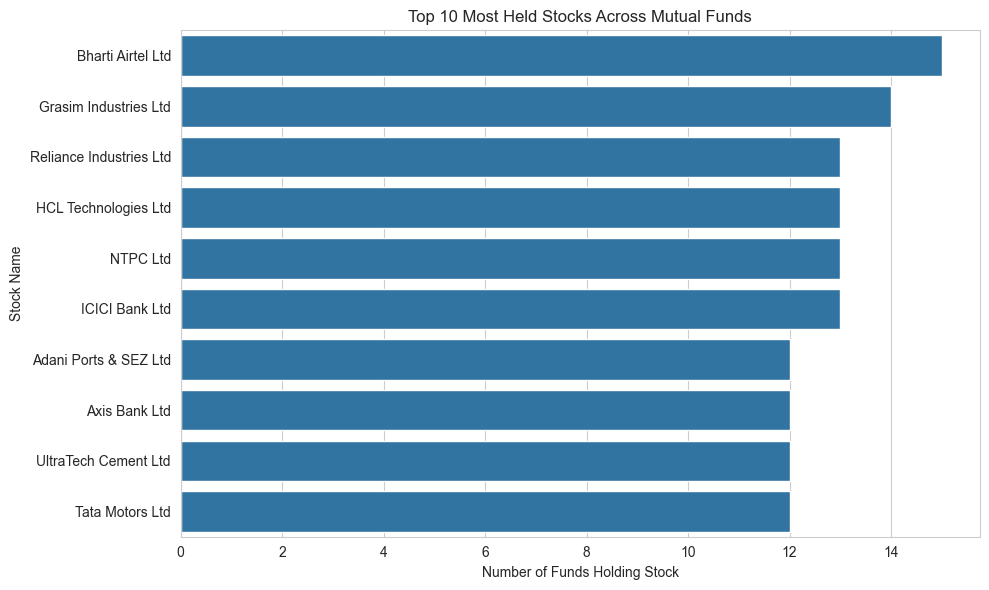

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_stocks,
    x="fund_count",
    y="stock_name"
)

plt.title("Top 10 Most Held Stocks Across Mutual Funds")
plt.xlabel("Number of Funds Holding Stock")
plt.ylabel("Stock Name")

plt.tight_layout()

plt.savefig("../reports/top_holdings.png")
plt.show()

## Top Holdings Insights

Bharti Airtel emerged as the most widely held stock across mutual fund portfolios, followed by Grasim Industries, Reliance Industries, HCL Technologies, and ICICI Bank. The results indicate a strong preference for large-cap companies operating in telecom, banking, technology, energy, and industrial sectors. These companies are widely represented because of their market leadership, liquidity, and long-term growth potential.

In [26]:
risk_return = performance[
    ["scheme_name", "return_3yr_pct", "std_dev_ann_pct"]
].dropna()

risk_return.head()

,scheme_name,return_3yr_pct,std_dev_ann_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,14.0
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,14.0
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,25.0
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,25.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,4.0


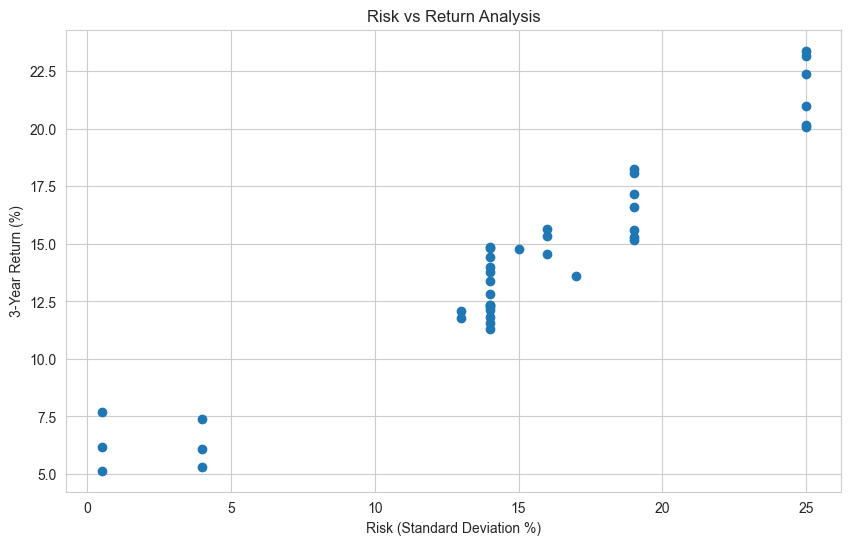

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    risk_return["std_dev_ann_pct"],
    risk_return["return_3yr_pct"]
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Risk (Standard Deviation %)")
plt.ylabel("3-Year Return (%)")

plt.savefig("../reports/risk_return.png")
plt.show()

# Risk vs Return Insights

The scatter plot demonstrates a positive relationship between risk and return across mutual fund schemes. Low-risk funds generated relatively lower returns, while schemes with higher volatility achieved stronger long-term performance. The analysis highlights the fundamental investment principle that higher returns are generally associated with greater risk exposure.

In [28]:
fund_house_aum = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fund_house_aum

,fund_house,aum_crore
0,SBI Mutual Fund,8491000
1,ICICI Prudential MF,6293000
2,HDFC Mutual Fund,5732000
3,Nippon India MF,3909000
4,Kotak Mahindra MF,3502000
5,Aditya Birla Sun Life MF,3077000
6,UTI Mutual Fund,2681000
7,Axis Mutual Fund,2521000
8,Mirae Asset MF,1561000
9,DSP Mutual Fund,1409000


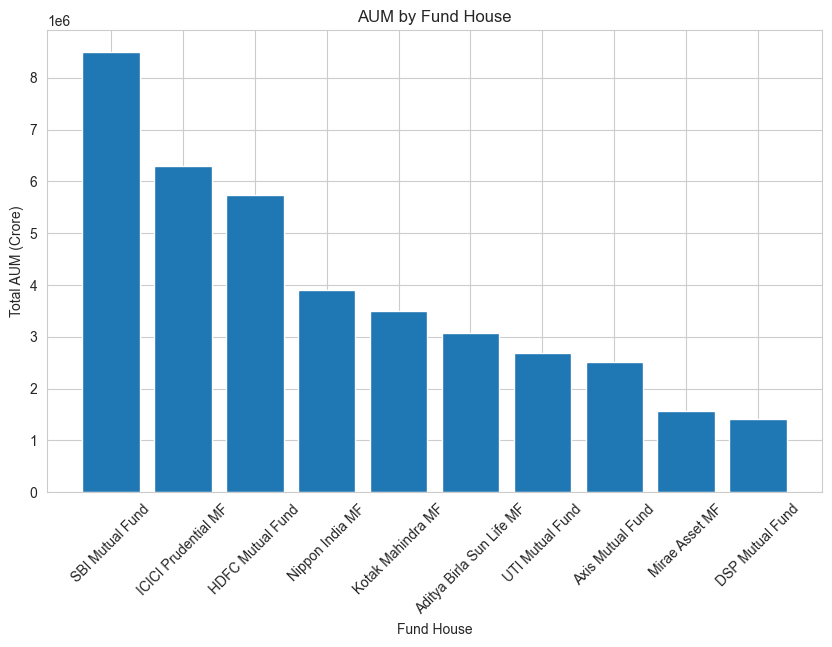

In [29]:
plt.figure(figsize=(10,6))

plt.bar(
    fund_house_aum["fund_house"],
    fund_house_aum["aum_crore"]
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Total AUM (Crore)")

plt.xticks(rotation=45)

plt.savefig("../reports/fund_house_aum.png")
plt.show()

# Fund House AUM Insights

SBI Mutual Fund manages the largest total AUM among all fund houses, followed by ICICI Prudential Mutual Fund and HDFC Mutual Fund. The higher AUM values indicate stronger investor participation and market presence. Large asset bases often reflect investor confidence, wider product offerings, and established brand reputation within the mutual fund industry.

In [30]:
category_count = (
    performance["category"]
    .value_counts()
    .reset_index()
)

category_count.columns = ["category", "count"]

category_count

,category,count
0,Large Cap,14
1,Mid Cap,7
2,Small Cap,6
3,Liquid,3
4,Gilt,2
5,Flexi Cap,2
6,Short Duration,1
7,Value,1
8,Index/ETF,1
9,Index,1


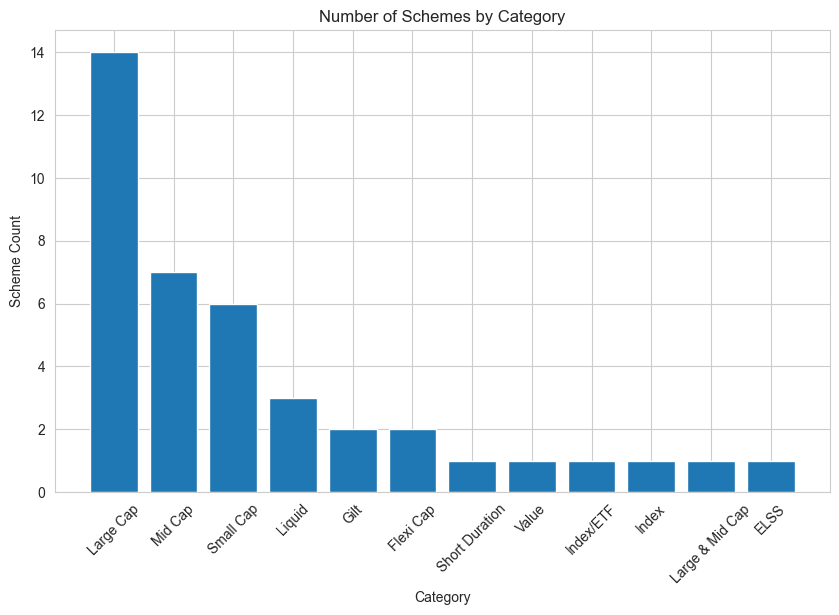

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    category_count["category"],
    category_count["count"]
)

plt.title("Number of Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Scheme Count")

plt.xticks(rotation=45)

plt.savefig("../reports/category_count.png")
plt.show()

# Fund Category Distribution

This chart presents the number of schemes available in each mutual fund category. Categories with a larger number of schemes offer investors more investment choices and indicate stronger product focus from asset management companies.

In [32]:
fund_house_count = (
    performance["fund_house"]
    .value_counts()
    .head(10)
    .reset_index()
)

fund_house_count.columns = ["fund_house", "count"]

fund_house_count

,fund_house,count
0,SBI Mutual Fund,5
1,HDFC Mutual Fund,5
2,ICICI Prudential MF,5
3,Nippon India MF,5
4,Kotak Mahindra MF,4
5,Axis Mutual Fund,4
6,Aditya Birla Sun Life MF,3
7,UTI Mutual Fund,3
8,Mirae Asset MF,3
9,DSP Mutual Fund,3


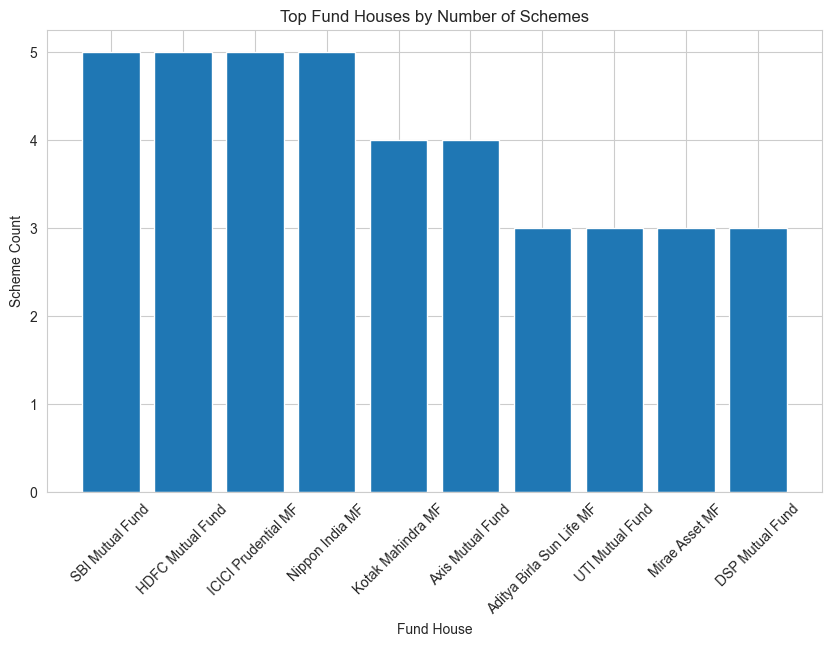

In [33]:
plt.figure(figsize=(10,6))

plt.bar(
    fund_house_count["fund_house"],
    fund_house_count["count"]
)

plt.title("Top Fund Houses by Number of Schemes")
plt.xlabel("Fund House")
plt.ylabel("Scheme Count")

plt.xticks(rotation=45)

plt.savefig("../reports/fund_house_scheme_count.png")
plt.show()

# Fund House Scheme Distribution

SBI Mutual Fund, ICICI Prudential Mutual Fund, HDFC Mutual Fund, and Nippon India Mutual Fund offer the highest number of schemes among the selected fund houses. A larger number of schemes indicates broader product diversification and the ability to cater to different investor risk profiles and investment objectives. The distribution suggests that leading fund houses maintain a wide range of offerings across multiple fund categories to attract diverse investor segments.

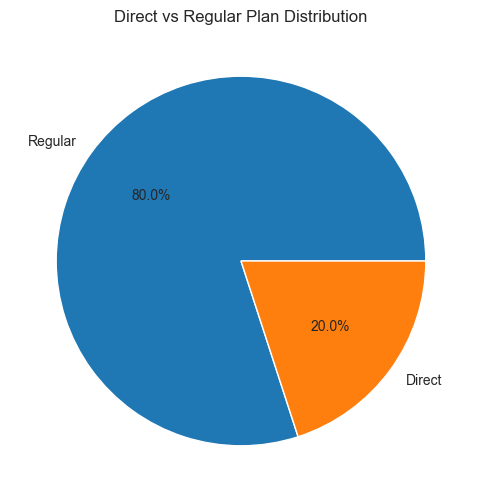

In [34]:
plan_distribution = (
    performance["plan"]
    .value_counts()
    .reset_index()
)

plan_distribution.columns = ["plan", "count"]

plt.figure(figsize=(6,6))

plt.pie(
    plan_distribution["count"],
    labels=plan_distribution["plan"],
    autopct="%1.1f%%"
)

plt.title("Direct vs Regular Plan Distribution")

plt.savefig("../reports/plan_distribution.png")
plt.show()

# Direct vs Regular Plan Distribution

Regular plans account for the majority of mutual fund schemes, representing 80% of the total schemes analyzed, while Direct plans contribute 20%. This distribution reflects the continued importance of distributor-led investment channels in the mutual fund industry. Direct plans generally offer lower expense ratios because they eliminate intermediary commissions, whereas Regular plans provide investors with advisory and distribution support.

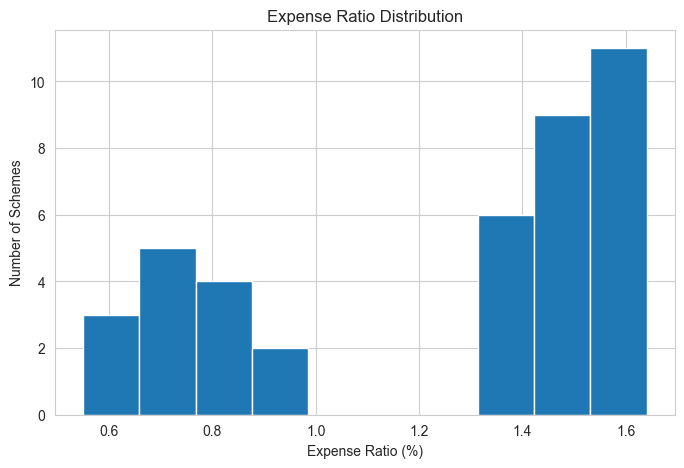

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Schemes")

plt.savefig("../reports/expense_ratio_distribution.png")
plt.show()

# Expense Ratio Distribution

The expense ratio distribution shows two major clusters of mutual fund schemes. A significant number of schemes have expense ratios between 1.3% and 1.6%, while a smaller group falls between 0.5% and 1.0%. This indicates that most funds operate within a moderate-to-high expense range, reflecting active fund management costs. Lower expense ratio funds may provide better cost efficiency for investors, whereas higher expense ratios are often associated with actively managed strategies that aim to generate superior returns.

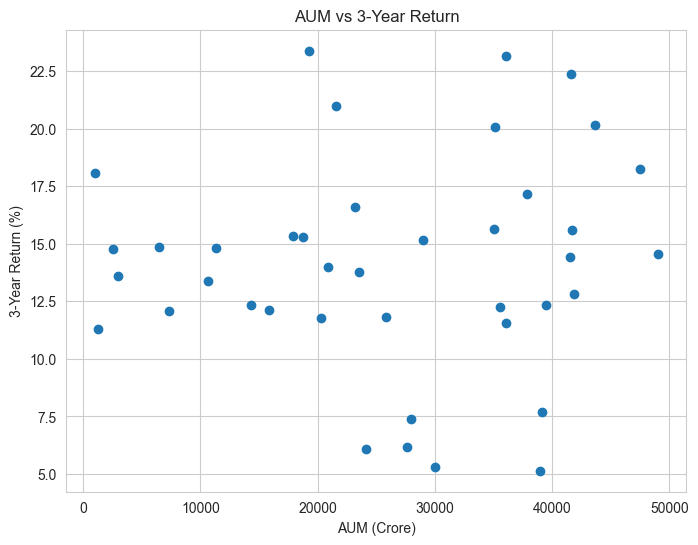

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    performance["aum_crore"],
    performance["return_3yr_pct"]
)

plt.title("AUM vs 3-Year Return")
plt.xlabel("AUM (Crore)")
plt.ylabel("3-Year Return (%)")

plt.savefig("../reports/aum_vs_return.png")
plt.show()

# AUM vs 3-Year Return Analysis

The scatter plot shows no strong linear relationship between Assets Under Management (AUM) and 3-year returns. Funds with both high and low AUM values are spread across a wide range of returns, indicating that larger fund size does not necessarily guarantee better performance. Several high-return funds are observed across different AUM levels, suggesting that factors such as fund strategy, portfolio composition, and management quality have a greater influence on returns than fund size alone.

# Final Conclusion

The exploratory analysis reveals key patterns in mutual fund performance, investor demographics, portfolio allocation, and fund management characteristics. Equity-oriented categories such as Small Cap and Mid Cap funds delivered stronger long-term returns, while portfolio allocations showed a concentration in Banking, IT, and Pharma sectors. Fund size (AUM) demonstrated limited correlation with returns, highlighting the importance of fund strategy over scale. Overall, the analysis provides a comprehensive view of market trends, risk-return dynamics, and portfolio composition across the selected mutual fund universe.